In [ ]:
# ============================================================
# import libraries
# ============================================================
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# O'zingizning ma'lumotingizni tuzing (masalan: mashina yurgan masofa va yoqilg'i sarfi, yoki o'qish vaqti va baho).

# ============================================================
# data
# ============================================================
# x (xonalar soni): [1, 2, 3, 4, 5]
# y (elektr sarfi, $\times 50$ kVt·soat): [3, 5, 8, 10, 14]
w, b = sp.symbols("w b")
x_data = np.array([1, 2, 3, 4, 5])
y_data = np.array([3, 5, 8, 10, 14])

In [ ]:
# ============================================================
# 1) SymPy bilan cost function va qisman hosilalarni yozing
# ============================================================
C = sum((w * xv + b - yv) ** 2 for xv, yv in zip(x_data, y_data)) / len(x_data)
cost_func = sp.lambdify((w, b), C, "numpy")
print(f"algebraic cost func -> {sp.expand(C)}")
# algebraic cost func -> b**2 + 6*b*w - 16*b + 11*w**2 - 294*w/5 + 394/5

print("\n" + "-" * 30)

dC_dw = sp.diff(C, w)
dC_db = sp.diff(C, b)

print(f"dC_dw -> {dC_dw} \ndC_db -> {dC_db}")
# dC_dw -> 6*b + 22*w - 294/5
# dC_db -> 2*b + 6*w - 16

algebraic cost func -> b**2 + 6*b*w - 16*b + 11*w**2 - 294*w/5 + 394/5

------------------------------
dC_dw -> 6*b + 22*w - 294/5 
dC_db -> 2*b + 6*w - 16


In [ ]:
# ============================================================
# 2) sp.solve bilan analitik optimal (w, b) ni toping
# ============================================================
solution = sp.solve([dC_dw, dC_db], [w, b])
w_optimal = float(solution[w])
b_optimal = float(solution[b])

print("\n" + "-" * 30)

print(f"w-optimal -> {w_optimal}, b-optimal -> {b_optimal}")
# w-optimal -> 2.7, b-optimal -> -0.1


------------------------------
w-optimal -> 2.7, b-optimal -> -0.1


In [ ]:
# ============================================================
# 3) Gradient descentni yozing va 100+ qadamdan keyingi natijani analitik yechim bilan solishtiring
# ============================================================
x = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 8, 10, 14])
w, b, lr = 0.0, 0.0, 0.04

for step in range(110):
    pred = w * x + b
    dw = np.mean(2 * (pred - y) * x)
    db = np.mean(2 * (pred - y))
    w = w - lr * dw
    b = b - lr * db

print("\n" + "-" * 30)
print(f"step 110: w -> {w:.3f},  b -> {b:.3f},  cost_func -> {cost_func(w, b):.4f}")
# step 110: w -> 2.597,  b -> 0.273,  cost_func -> 0.2454

# 110-qadamda w (2.597) analitik optimalga (2.7) ancha yaqinlashdi,
# b (0.273) esa gradient sustligi sababli sekinroq yaqinlashmoqda (optimal: -0.1).
# Global minimumga to'liq yetish uchun qadamlar sonini oshirish yoki learning rateni oshirish kerak.


------------------------------
step 110: w -> 2.651,  b -> 0.076,  cost_func -> 0.2256


In [ ]:
# ============================================================
# 4) Kamida ikki xil learning rate sinab ko'ring va farqni 2–3 jumlada izohlang
# ============================================================

# lr = 0.02
# step 110: w -> 2.597,  b -> 0.273,  cost_func -> 0.2454

# lr = 0.03
# step 110: w -> 2.629,  b -> 0.157,  cost_func -> 0.2320

# lr = 0.04
# step 110: w -> 2.651,  b -> 0.076,  cost_func -> 0.2256

# Learning rate oshirilishi (0.02 dan 0.04 gacha) (cost_func) tezroq kamayishini ta'minladi.
# Yuqoriroq qadam o'lchami bilan parametrlar (ayniqsa, b) analitik optimal yechimga (2.7 va -0.1) ancha tezroq yaqinlashdi.

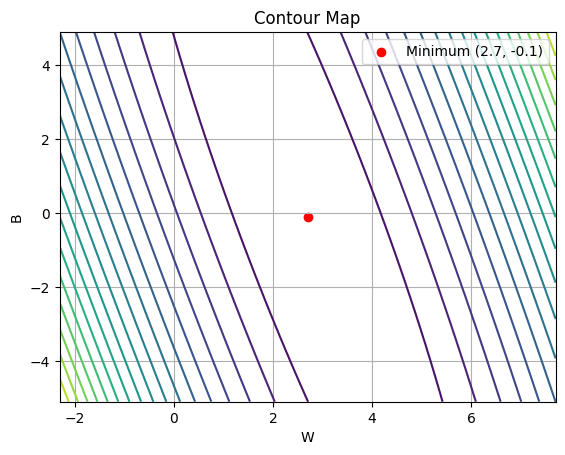

In [ ]:
# ============================================================
# 5) contur map
# ============================================================
W, B = np.meshgrid(
    np.linspace(w_optimal + 5, w_optimal - 5, 100),
    np.linspace(b_optimal + 5, b_optimal - 5, 100),
)

plt.contour(W, B, cost_func(W, B), 20)
plt.scatter([w_optimal], [b_optimal], color="red", label="Minimum (2.7, -0.1)")

plt.title("Contour Map")
plt.xlabel("W")
plt.ylabel("B")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# O'zingizning binary (0/1) ma'lumotingizni tuzing (masalan: mijoz xarid qildimi yoki yo'qmi).

# ============================================================
# data
# ============================================================
# x (saytdagi vaqt, daqiqa): [0.5, 1.2, 2.0, 3.5, 4.2, 5.0]
# y (xarid holati): [0, 0, 0, 1, 1, 1]
z = sp.symbols("z")
x = np.array([0.5, 1.2, 2.0, 3.5, 4.2, 5.0])
y = np.array([0, 0, 0, 1, 0, 1])

In [ ]:
# ============================================================
# 1) Sigmoid va uning hosilasini SymPy bilan tekshiring ("ayirma = 0" usuli)
# ============================================================
sigmoid = 1 / (1 + sp.exp(-z))
d_sigmoid = sp.diff(sigmoid, z)
print(f"d-sigmoid -> {sp.simplify(d_sigmoid)}")  # d-sigmoid -> 1/(4*cosh(z/2)**2)
print(sp.simplify(d_sigmoid - sigmoid * (1 - sigmoid)))  # 0

d-sigmoid -> 1/(4*cosh(z/2)**2)
0


In [ ]:
# ============================================================
# 2) Logistik regressiyani gradient descent bilan o'qiting
# ============================================================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


w, b, lr = 0.0, 0.0, 0.1

for step in range(2000):
    p = sigmoid(w * x + b)
    dw = np.mean((p - y) * x)
    db = np.mean(p - y)
    w -= lr * dw
    b -= lr * db


print(f"step 2000: w -> {w:.3f},  b -> {b:.3f}")
# step 2000: w -> 2.729,  b -> -7.167

step 2000: w -> 1.278,  b -> -4.818


AUC -> 0.875


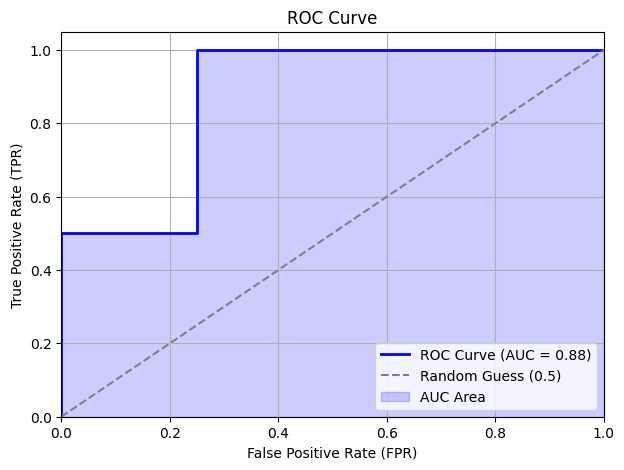

In [ ]:
# ============================================================
# 3) ROC egri chizig'ini chizing va AUC ni np.trapezoid bilan hisoblang
# ============================================================
pred = sigmoid(w * x + b)
tpr, fpr = [0.0], [0.0]
for t in np.sort(np.unique(pred))[::-1]:
    prediction = (pred >= t).astype(int)
    tpr.append(np.sum((prediction == 1) & (y == 1)) / np.sum(y == 1))
    fpr.append(np.sum((prediction == 1) & (y == 0)) / np.sum(y == 0))

auc = np.trapezoid(tpr, fpr)
print(f"AUC -> {auc:.3f}")
# AUC -> 0.875

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess (0.5)")
plt.fill_between(fpr, tpr, alpha=0.2, color="blue", label="AUC Area")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.title("ROC Curve")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")

plt.legend()

plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# 4) Natijani sklearn.metrics.roc_auc_score bilan solishtiring
# ============================================================
# hali bu mavzu o'tilmagan